In [1]:
import pandas as pd
import psycopg2
import psycopg2.extras
import matplotlib.pyplot as plt
import warnings

from matplotlib.pyplot import barh

warnings.filterwarnings('ignore')

# pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

VERBINDUNG = {
    'host': 'localhost',
    'dbname': 'klinik',
    'user': 'postgres',
    'password': 'Awb2tz',
    'port': '5432'
}

# Verbindung testen:

try:
    conn = psycopg2.connect(**VERBINDUNG)
    print(' Verbindung zur Klinik erfolgreich')
    conn.close()
except Exception as e:
    print(' Fehler bei der Verbindung zur Klinik: ', e)

 Verbindung zur Klinik erfolgreich


In [8]:
## Block 2: Daten direst aus postgres in pandas laden

# `pandas.read_sql()` führt eine SQL-Abfrage aus und gibt das Ergebnis direkt als DataFrame zurück. Das ist eine zeile Code statt .fetchall und loops.

conn = psycopg2.connect(**VERBINDUNG)

# Patienten laden:

df_patienten  = pd.read_sql(
    '''
    SELECT
        p.id,
        p.vorname,
        p.nachname,
        p.geburtsdatum,
        p.versicherung,
        p.aufgenommen,
        a.name AS arzt,
        a.fachgebiet
    FROM patientendaten.patienten AS p
    LEFT JOIN personal.aerzte AS a ON p.behandelnder_arzt_id = a.id
    ORDER BY p.aufgenommen DESC
    ''',
    conn,
    parse_dates = ['geburtsdatum', 'aufgenommen']
)

# Diagnosen laden:
df_diagnosen = pd.read_sql(
    '''
    SELECT
        d.id,
        d.patient_id,
        d.icd_code,
        d.beschreibung,
        d.vertraulich,
        d.erstellt_am,
        a.name AS arzt,
        a.fachgebiet
    FROM patientendaten.diagnosen AS d
    LEFT JOIN personal.aerzte AS a ON d.arzt_id = a.id
    ORDER BY d.erstellt_am DESC
    ''',
    conn,
    parse_dates = ['erstellt_am']
)

# Medikamente laden
df_medikamente = pd.read_sql(
    '''
    SELECT
        m.id,
        m.patient_id,
        m.bezeichnung,
        m.dosierung,
        m.von_datum,
        m.bis_datum,
        a.name AS arzt
    FROM patientendaten.medikamente AS m
    LEFT JOIN personal.aerzte AS a ON m.arzt_id = a.id
    ''',
    conn,
    parse_dates = ['von_datum', 'bis_datum']
)

conn.close()
print(f' Patienten:      {len(df_patienten)} Zeilen')
print(f' Diagnosen:      {len(df_diagnosen)} Zeilen')
print(f' Medikamente:    {len(df_medikamente)} Zeilen')
print(f' Medikamente:     {len(df_medikamente)} Zeilen')

 Patienten:      63 Zeilen
 Diagnosen:      164 Zeilen
 Medikamente:    102 Zeilen
Medikamente:     102 Zeilen


In [12]:
import numpy as np
from datetime import date

# Alter berechnen:
heute = pd.Timestamp(date.today())
df_patienten['alter'] = (
(heute - df_patienten['geburtsdatum']).dt.days / 365.25
).astype(int)

# Altersgruppen kategorisieren
df_patienten['altersgruppe'] = pd.cut(
    df_patienten['alter'],
    bins=[0, 30, 50, 65, 120],
    labels=['Unter 30', '30-50', '51-65', 'Über 65']
)

# Aufnahme-Monat extrahieren
df_patienten['aufnahme_monat'] = df_patienten['aufgenommen'].dt.to_period('M')

# fehlende versicherung mit 'Unbekannt' füllen
df_patienten['versicherung'] = df_patienten['versicherung'].fillna('Unbekannt')

print('Neue spalten hinzugefügt: alter, altersgruppe, aufnahme_monat')
df_patienten[['vorname', 'nachname','alter', 'altersgruppe', 'versicherung', 'aufnahme_monat' ]].head(8)

Neue spalten hinzugefügt: alter, altersgruppe, aufnahme_monat


,vorname,nachname,alter,altersgruppe,versicherung,aufnahme_monat
0,Max,Mustermann,40,30-50,Techniker Krankenkasse,2026-04
1,Lukas,Mustermann,40,30-50,techniker Krankenkasse,2026-04
2,Max,Mustermann,40,30-50,techniker Krankenkasse,2026-04
3,Franz,Schwarz,74,Über 65,Signal Iduna,2025-12
4,Walter,Meyer,73,Über 65,IKK,2025-12
5,Michael,Huber,32,30-50,Barmer,2025-12
6,Christian,Weber,78,Über 65,HEK,2025-11
7,Wolfgang,Mayer,62,51-65,Privat GmbH,2025-08


## Auswertung und KPIs
jetzt rechnen wir mal. pandas macht das mit einer zeile-code

In [2]:
# KPI 1: patienten nach versicherung

versicherung_stats = (
    df_patienten['versicherung'].value_counts().reset_index()
)
versicherung_stats.columns = ['versicherung', 'anzahl']
versicherung_stats['anteil_pct'] = (
    versicherung_stats['anzahl'] / len(df_patienten) * 100
).round(1)
print('Patienten nach Versicherung:')
print(versicherung_stats.to_string(index=False))



['Banane', 'Birne', 'apfel', 'erdbeere']


In [15]:
# KPI 2: Patienten nach Altersgruppe
print('Altersverteilung der Patienten:')
altersgruppe_stats = (df_patienten['altersgruppe'].value_counts().sort_index())
print(altersgruppe_stats)
print('Durchschnittsalter')
print(f'Durchschnittsalter : {df_patienten['alter'].mean():.1f} jahre')
print(f'Jüngster Patient: {df_patienten['alter'].min():.1f} jahre')
print(f'ältester Patient: {df_patienten['alter'].max():.1f} jahre')



Altersverteilung der Patienten:
altersgruppe
Unter 30     4
30-50       20
51-65       20
Über 65     19
Name: count, dtype: int64
Durchschnittsalter
Durchschnittsalter : 54.5 jahre
Jüngster Patient: 27.0 jahre
ältester Patient: 81.0 jahre


In [19]:
# KPI 3: Diagnosen nach ICD-Bereich (und optional Arzt)
# Entferne einfach die eckigen Klammern um den Ausdruck
diagnose_stats = df_diagnosen.groupby(['icd_code', 'beschreibung']).size().reset_index(name='anzahl').sort_values('anzahl', ascending=False).head(10)

print('Top 10 Diagnosen:')
print(diagnose_stats.to_string(index=False))

Top 10 Diagnosen:
icd_code                                          beschreibung  anzahl
   I21.0                 Akuter transmuraler Vorderwandinfarkt      13
   J18.0 Lobärpneumonie durch nicht näher bezeichneten Erreger      12
     G35                                     Multiple Sklerose      11
   C34.1            Bösartige Neubildung des Lungenoberlappens      11
   G43.0                                     Migräne ohne Aura      11
   M51.1                Lumbale und andere Bandscheibenschäden      10
   K40.2             Bilaterale Leistenhernie ohne Obstruktion      10
   Z51.1                                 Chemotherapie-Sitzung      10
   N20.0                                           Nierenstein       9
   J44.1                          COPD mit akuter Exazerbation       9


In [20]:
# KPI 4: Diagnosen nach Arzt

arzt_stats = (
    df_diagnosen.groupby(['arzt', 'fachgebiet']).agg(diagnosen_gesamt=('id', 'count'), vertraulich = ('vertraulich', 'sum'),)
).reset_index().sort_values('diagnosen_gesamt', ascending=False
)

print('Diagnosen nach Arzt:')
print(arzt_stats.to_string(index=False))

Diagnosen nach Arzt:
              arzt      fachgebiet  diagnosen_gesamt  vertraulich
   Dr. Felix Klein       Chirurgie                32            8
    Dr. Nina Braun       Pädiatrie                27           12
  Dr. Jonas Becker      Orthopädie                24            5
    Dr. Anna Weber     Kardiologie                22            5
   Dr. Mark Schulz Anästhesiologie                20            5
Dr. Sarah Hoffmann  Innere Medizin                19            7
  Dr. Laura Müller      Neurologie                12            1
   Dr. Tim Richter      Radiologie                 8            2


In [22]:
# kpi 5: Häufigste Medikamente
medikament_stats = (
    df_medikamente['bezeichnung'].value_counts().head(10).reset_index()
)
medikament_stats.columns = ['medikament', 'verschreibungen']

print('Top 10 Medikamente:')
print(medikament_stats.to_string(index=False))

Top 10 Medikamente:
       medikament  verschreibungen
 L-Thyroxin 100µg               13
 Pantoprazol 40mg                9
  Prednisolon 5mg                8
  Metformin 500mg                8
Amoxicillin 500mg                8
   Bisoprolol 5mg                7
  Cefuroxim 500mg                7
    Amlodipin 5mg                7
  Diclofenac 75mg                7
     Ramipril 5mg                7


## block 5: Visualisierung im Notebook
matplotlib ist die Standardbibliothek für Visualisierung in Python. Es gibt auch andere wie seaborn, plotly, etc. aber matplotlib ist am weitesten verbreitet und funktioniert gut für einfache Diagramme.

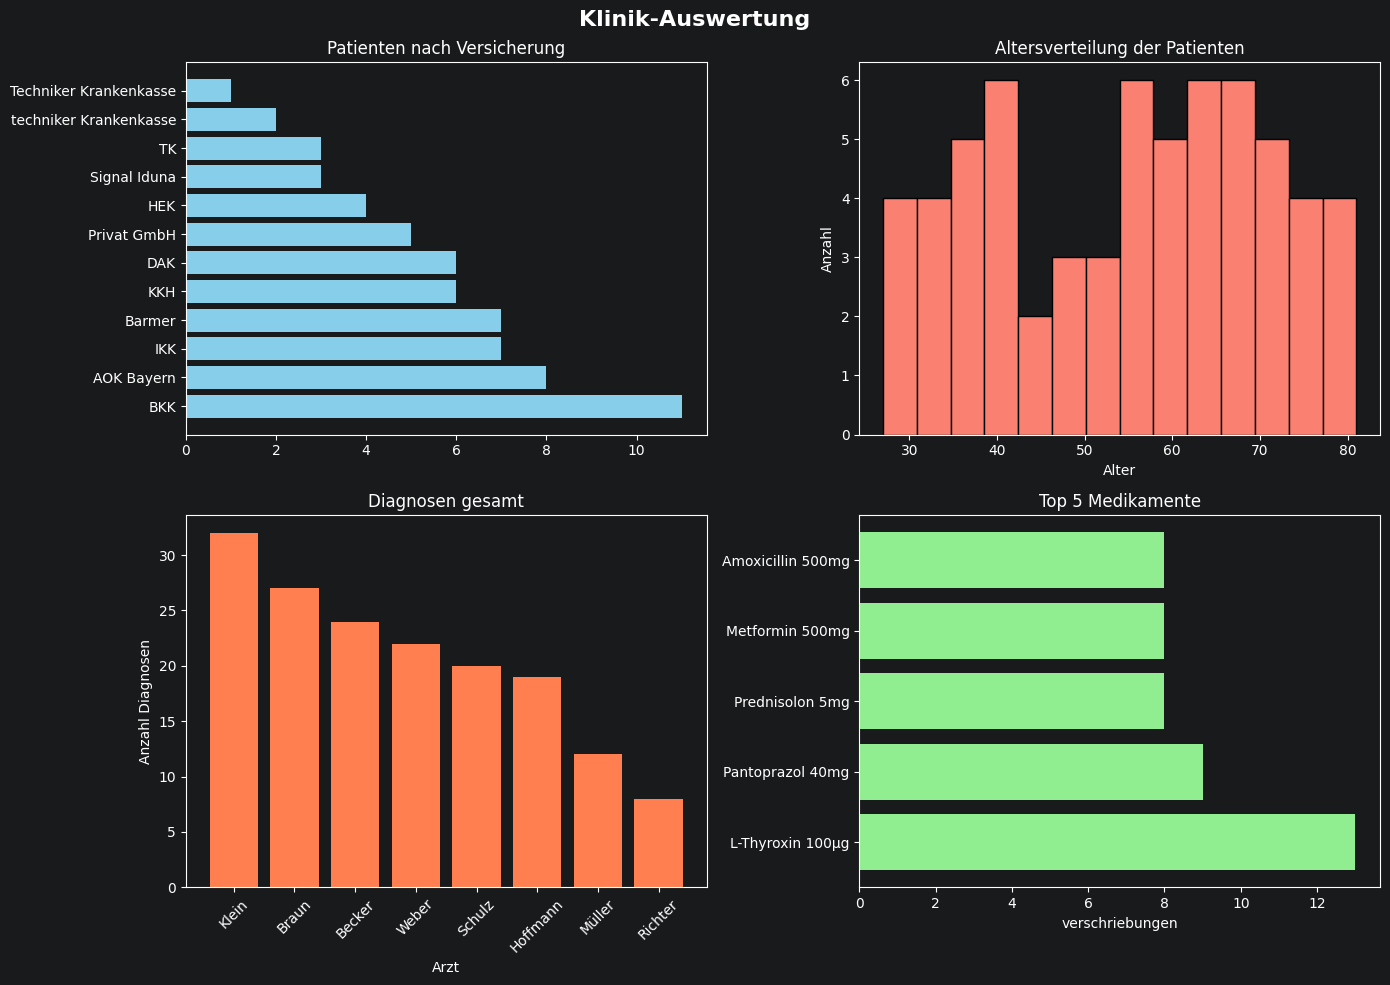

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fehler korrigiert: suptitle statt subtitle
fig.suptitle('Klinik-Auswertung', fontsize=16, fontweight='bold')

# Diagramm 1: Patienten nach Versicherung (Balken)
ax1 = axes[0, 0]

# 2. Fehler korrigiert: Punkt statt Komma vor barh
ax1.barh(versicherung_stats['versicherung'], versicherung_stats['anzahl'], color='skyblue')

# Optional: Titel für das Unterdiagramm setzen
ax1.set_title('Patienten nach Versicherung')



ax2 = axes[0, 1]
ax2.hist(df_patienten['alter'], bins=14, color='salmon', edgecolor='black')
ax2.set_title('Altersverteilung der Patienten')
ax2.set_xlabel('Alter')
ax2.set_ylabel('Anzahl')

# Diagramm 3: Diagnosen pro Arzt (Balken)
ax3 = axes[1, 0]
ax3.bar([name.split()[-1] for name in arzt_stats['arzt']],
        arzt_stats['diagnosen_gesamt'],
        color='coral',
        )
ax3.set_title('Diagnosen gesamt')
ax3.set_xlabel('Arzt')
ax3.set_ylabel('Anzahl Diagnosen')
ax3.tick_params(axis='x', rotation=45)

# Diagramm 4: Top 5 Medikamente (Balken horizontal)
ax4 = axes[1, 1]
top5 = medikament_stats.head(5)
ax4.barh(top5['medikament'], top5['verschreibungen'], color='lightgreen')
ax4.set_title('Top 5 Medikamente')
ax4.set_xlabel('verschriebungen')

plt.tight_layout()
plt.savefig('klinikauswertung.png', dpi=300, bbox_inches='tight')
plt.show()

## Block 6: Formatierten Excel Bericht erstellen

`openpyxl` ist eine Bibliothek, die es ermöglicht, Excel-Dateien zu erstellen und zu bearbeiten. Mit `pandas` können wir unsere DataFrames direkt in Excel-Tabellen umwandeln und mit `openpyxl` können wir das Layout und die Formatierung anpassen.

In [36]:
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side, numbers
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, Reference
from datetime import datetime


# Farben definieren
DUNKELBLAU = '1F4E78'
HELLBLAU = 'D9E1F2'
GRAU = 'D9D9D9'
WEISS = 'FFFFFF'

def kopfzeile_formatieren(ws, zeile_nr, farbe=DUNKELBLAU):
    """Formatiert die Kopfzeile einer Tabelle mit fetter Schrift, zentrierter Ausrichtung und Hintergrundfarbe."""
    for cell in ws[zeile_nr]:
        cell.font = Font(bold=True, color=WEISS, size=12)
        cell.fill = PatternFill('solid', fgColor=farbe)
        cell.alignment = Alignment(horizontal='center', vertical='center')

def spaltenbreite_anpassen(ws):
    """Passt die Spaltenbreite basierend auf dem längsten Eintrag in jeder Spalte an."""
    for column_cells in ws.columns:
        max_length = max(len(str(cell.value or '')) for cell in column_cells)
        ws.column_dimensions[column_cells[0].column_letter].width = min(max_length + 4, 45)  # Maximal 45 Zeichen breit

print("Hilffuktion definiert.")

Hilffuktion definiert.


In [45]:
# Excel workbook definieren

wb = Workbook()

#1. Tabellenblatt: Zusammenfassung

ws1 = wb.active
ws1.title = 'Zusammenfassung'

# Titel:
ws1['A1'] = 'Klinik-Auswertung'
ws1['A1'].font = Font(bold=True, color=DUNKELBLAU, size=16)
ws1['A2'] = f'Erstellt am: {datetime.now().strftime("%d/%m/%Y %H:%M")}'
ws1['A2'].font = Font( color=GRAU, size=12)

# KPI-Karten:
ws1['A4'] = 'Kennzahl'
ws1['B4'] = 'Wert'
kopfzeile_formatieren(ws1, 4)

kpis = [
    ('Patienten gesamt', len(df_patienten)),
    ('Diagnosen gesamt', len(df_diagnosen)),
    ('Medikamente gesamt', len(df_medikamente)),
    ('Durchschnittsalter', f"{df_patienten['alter'].mean():.1f} Jahre"),
    ('Jüngster Patient', f"{df_patienten['alter'].min():.1f} Jahre"),
    ('Ältester Patient', f"{df_patienten['alter'].max():.1f} Jahre"),
    ('Vertrauliche Diagnosen', int(df_diagnosen['vertraulich'].sum())),
    ('Behandelnde Ärzte', df_diagnosen['arzt'].nunique()),
        ]

for i, (name, wert) in enumerate(kpis, start = 5):
    ws1[f'A{i}'] = name
    ws1[f'B{i}'] = wert
    if i % 2 == 0:
        for col in ['A', 'B']:
            ws1[f'{col}{i}'].fill = PatternFill('solid', fgColor=HELLBLAU)


spaltenbreite_anpassen(ws1)


# Tabellenblatt 2: versicherungen
ws2 = wb.create_sheet("Versicherungen")
ws2['A1'] = 'Patienten nach Versicherung'
ws2['A1'].font = Font(bold=True, color=DUNKELBLAU, size=14)


# Daten einfügen:
headers = ['versicherung', 'Anzahl der Patienten', 'Anteil in %']
ws2.append([])
ws2.append(headers)

kopfzeile_formatieren(ws2, ws2.max_row)

for j, row in versicherung_stats.iterrows():
    ws2.append([row['versicherung'], row['anzahl'], row['anteil_pct']])


# Balkendiagramm hinzufügen:
chart = BarChart()
chart.title = "patienten nach versicherung"
chart.style = 10
chart.height = 12
chart.width = 18

data = Reference(ws2, min_col=2, min_row=3, max_row=ws2.max_row)
labels = Reference(ws2, min_col=1, min_row=4, max_row=ws2.max_row)
chart.add_data(data,titles_from_data=True)
chart.set_categories(labels)
ws2.add_chart(chart, 'E3')
spaltenbreite_anpassen(ws2)

#3. Diagnosen

ws3 = wb.create_sheet("häufite Diagnosen")
ws3['A1'] = 'Top 10 häufigste Diagnosen'
ws3['A1'].font = Font(bold=True, color=DUNKELBLAU, size=12)
ws3.append([])
ws3.append(['ICD-Code', 'beschreibung', 'Anzahl'])
kopfzeile_formatieren(ws3, ws3.max_row)

for d, row in diagnose_stats.iterrows():
    ws3.append([row['icd_code'], row['beschreibung'], row['anzahl']])

    spaltenbreite_anpassen(ws3)

dateiname = f'klinikauswertung_{datetime.now().strftime("%y%m%d_%h%m")}.xlsx'
wb.save(dateiname)
print(f'Excel-Bericht "{dateiname}" wurde erfolgreich erstellt.')

Excel-Bericht "klinikauswertung_260504_May05.xlsx" wurde erfolgreich erstellt.
